In [1]:
import time
from ugot import ugot
got = ugot.UGOT()
got.initialize('192.168.1.191')
print("Hello World")
got.show_light_rgb_effect(0,255,0,3)
time.sleep(2)
got.turn_off_lights()

192.168.1.191:50051
Hello World


## Session 2

In [ ]:
import time
Laser1 = got.read_distance_data(21)

while Laser1 >10:
    speed = Laser1
    Laser1 = got.read_distance_data(21)

    if Laser1> 50:
        got.mecanum_move_xyz(0,50,0)
    else:
        got.mecanum_move_xyz(0,int(speed),0)
        print(f"The current speed is:{speed} cm/second ")

got.mecanum_stop()
print("It's too close to the wall, let's stop!")


1. Kp control

In [ ]:
import time
safe_distance = 10
Kp = 0.8

while True:
    current_distance = got.read_distance_data(21)

    error = current_distance-safe_distance
    print(f"The error is: {error}.")

    if error <1:
        got.mecanum_stop()
        break
    speed = Kp * error
    speed = max(min(speed,30),-10)
    print(f"The speed is: {speed} cm/s.")

    got.mecanum_move_xyz(0,int(speed),0)
    time.sleep(0.05)

The error is: 240.0.
The speed is: 30 cm/s.
The error is: 240.0.
The speed is: 30 cm/s.
The error is: 45.1.
The speed is: 30 cm/s.
The error is: -5.5.


The camera is on.


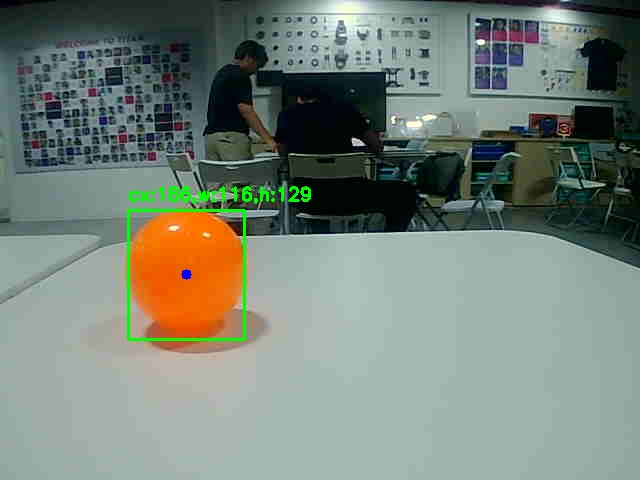

In [5]:
# bounding box with video
import time
import numpy as np
import cv2
from IPython.display import display, Image

# open camera
got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
if picture_raw is None:
    raise Exception("No camera data.")

# raw data to 1D array
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
if picture_bgr is None:
    raise Exception("Check the camera.")

# Use handle for live updates in Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(picture_jpg.tobytes()),display_id = True)

# Detect the color
lower_color = np.array([10,180,180])
upper_color = np.array([30,255,255])

# take video
start_time = time.time()
duration = 10

while time.time() - start_time < duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    if picture_bgr is None:
        continue
    picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(picture_hsv,lower_color,upper_color)
    # find contours
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area>1000:
            x,y,w,h = cv2.boundingRect(contour)
            # center of the bounding box
            center_x = x + w//2
            # draw a bounding box
            cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),2)
            # draw center point
            cv2.circle(picture_bgr,(center_x,y+h//2),5,(255,0,0),-1)
            # show text x,y,w,h and center
            text = f"cx:{center_x},w:{w},h:{h}"
            # keep text visible
            text_y = max(30,y-10)
            # draw text
            cv2.putText(picture_bgr,text,(x,text_y),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
    # update live video
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(picture_jpg.tobytes()))

    time.sleep(0.1)

In [8]:
def orange_ball_centralizing_approaching():
    # import libraries
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # create color range
    lower_color = np.array([10,180,180])
    upper_color = np.array([30,255,255])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)  

    # function 2: find color and return x,y,w,h
    def find_ball(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x + w//2
        if w> 100:    # close enough, stop
            got.mecanum_stop()
            return True
        elif center_x < 280:
            got.mecanum_move_xyz(-10,15,0)
        elif center_x > 360:
            got.mecanum_move_xyz(10,15,0)
        else:
            got.mecanum_move_xyz(0,10,0)
        
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(255,0,0),-1)

    # main program
    got.open_camera()
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(picture_jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_ball(frame)
        if result:
            if move_and_draw(frame,*result):  # close enough and stop
                break
        else:
            got.mecanum_stop()
        
        ok,picture_jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))
        
        time.sleep(0.05)

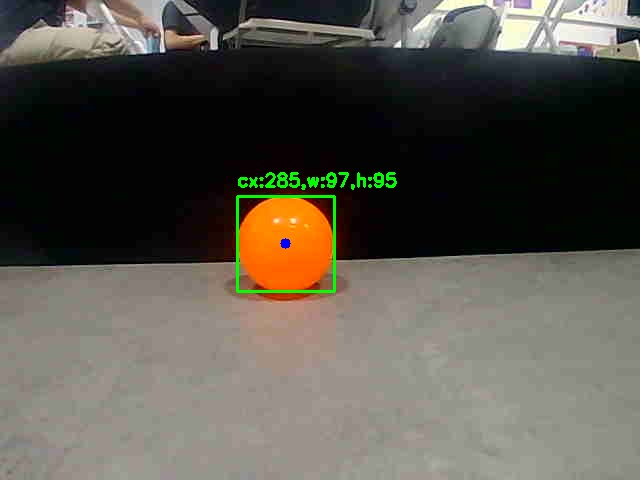

In [7]:
orange_ball_centralizing_approaching()

## Session 3

1. PID control

In [ ]:
# proportational control
import time
safe_distance = 10
Kp = 0.8

while True:
    current_distance = got.read_distance_data(21)
    error = current_distance- safe_distance
    print(f"The error value is : {error} cm.")

    if abs(error) < 1:
        got.mecanum_stop()
        break

    speed = Kp * error
    print(f"The speed is: {speed} cm/s.")
    got.mecanum_move_xyz(0,int(speed),0)
    time.sleep(0.05)

In [ ]:
# proportational + integral control
import time
safe_distance = 10
Kp = 0.8
Ki = 0.1

total_error = 0

while True:
    current_distance = got.read_distance_data(21)
    error = current_distance- safe_distance
    print(f"The error value is : {error} cm.")

    if abs(error) < 1:
        got.mecanum_stop() 
        break

    total_error += error
    total_error = max(min(total_error,100),-100)
    print(f"The total error is :{total_error}.")

    speed = Kp * error + Ki* total_error
    speed = max(min(speed,50),-50)
    print(f"The speed is: {speed} cm/s.")
    got.mecanum_move_xyz(0,int(speed),0)
    time.sleep(0.05)

In [ ]:
# Proportional + Integral + Derivative control 
safe_distance = 10
kp = 0.8
ki = 0.05
kd = 0.2

total_error = 0

current_distance = got.read_distance_data(21)   
error = current_distance - safe_distance
previous_error = error                           

while True:
    current_distance = got.read_distance_data(21)   
    error = current_distance - safe_distance

    if abs(error) < 1:
        got.mecanum_stop()
        break

    total_error += error
    total_error = max(min(total_error, 100), -100)

    derivative = error - previous_error

    speed = kp * error + ki * total_error + kd * derivative
    speed = max(min(speed, 30), -30)

    previous_error = error                          

    got.mecanum_move_xyz(0, int(speed), 0)
    time.sleep(0.05)

In [ ]:
def orange_ball_centralizing_approaching():
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # color range 
    lower_color = np.array([10, 180, 180])
    upper_color = np.array([30, 255, 255])

    # Kp values 
    kp_x = 0.08
    kp_y = 0.3

    frame_center = 320   
    target_w = 120       
    dead_zone_x = 20     
    dead_zone_y = 5

    # function 1: get bgr frame
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw, np.uint8), cv2.IMREAD_COLOR)

    # function 2: find ball, return bounding box 
    def find_ball(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV), lower_color, upper_color)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours, key=cv2.contourArea))

    # function 3: Kp move + draw 
    def move_and_draw(frame, x, y, w, h):
        center_x = x + w // 2

        # calculate errors 
        error_x = center_x - frame_center   
        error_y = target_w - w              

        # check: close enough AND centred 
        if abs(error_x) < dead_zone_x and abs(error_y) < dead_zone_y:
            got.mecanum_stop()
            return True

        # Kp outputs
        speed_x = int(kp_x * error_x)   
        speed_y = int(kp_y * error_y)   

        # clamp to safe speed range 
        speed_x = max(min(speed_x, 25), -25)
        speed_y = max(min(speed_y, 25), -25)

        got.mecanum_move_xyz(speed_x, speed_y, 0)

        # draw bounding box and debug info
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, f"cx:{center_x} ex:{error_x} ey:{error_y}",
                    (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.putText(frame, f"sx:{speed_x} sy:{speed_y}",
                    (x, y - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
        cv2.circle(frame, (center_x, y + h // 2), 5, (255, 0, 0), -1)
        cv2.line(frame, (frame_center, 0), (frame_center, frame.shape[0]), (100, 100, 100), 1)

    # main program 
    got.open_camera()
    ok, picture_jpg = cv2.imencode(".jpg", picture_bgr())
    handle = display(Image(picture_jpg.tobytes()), display_id=True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_ball(frame)
        if result:
            if move_and_draw(frame, *result):
                break
        else:
            got.mecanum_stop()

        ok, picture_jpg = cv2.imencode(".jpg", frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))

        time.sleep(0.05)

In [4]:
def orange_ball_centralizing_approaching():
    import time
    import numpy as np
    import cv2
    from IPython.display import display, Image

    # color range 
    lower_color = np.array([10, 180, 180])
    upper_color = np.array([30, 255, 255])

    # Kp values 
    kp_x = 0.08
    kp_y = 0.3

    frame_center = 320   
    target_w = 120       
    dead_zone_x = 20     
    dead_zone_y = 5

    # function 1: get bgr frame
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw, np.uint8), cv2.IMREAD_COLOR)

    # function 2: find ball, return bounding box 
    def find_ball(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV), lower_color, upper_color)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours, key=cv2.contourArea))

    # function 3: Kp move + draw 
    def move_and_draw(frame, x, y, w, h):
        center_x = x + w // 2

        # calculate errors 
        error_x = center_x - frame_center   
        error_y = target_w - w              

        # check: close enough AND centred 
        if abs(error_x) < dead_zone_x and abs(error_y) < dead_zone_y:
            got.mecanum_stop()
            return True

        # Kp outputs
        speed_x = int(kp_x * error_x)   
        speed_y = int(kp_y * error_y)   

        # clamp to safe speed range 
        speed_x = max(min(speed_x, 25), -25)
        speed_y = max(min(speed_y, 25), -25)

        got.mecanum_move_xyz(speed_x, speed_y, 0)

        # draw bounding box and debug info
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, f"cx:{center_x} ex:{error_x} ey:{error_y}",
                    (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.putText(frame, f"sx:{speed_x} sy:{speed_y}",
                    (x, y - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
        cv2.circle(frame, (center_x, y + h // 2), 5, (255, 0, 0), -1)


    # main program 
    got.open_camera()
    ok, picture_jpg = cv2.imencode(".jpg", picture_bgr())
    handle = display(Image(picture_jpg.tobytes()), display_id=True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_ball(frame)
        if result:
            if move_and_draw(frame, *result):
                break
        else:
            got.mecanum_stop()

        ok, picture_jpg = cv2.imencode(".jpg", frame)
        if ok:
            handle.update(Image(picture_jpg.tobytes()))

        time.sleep(0.05)

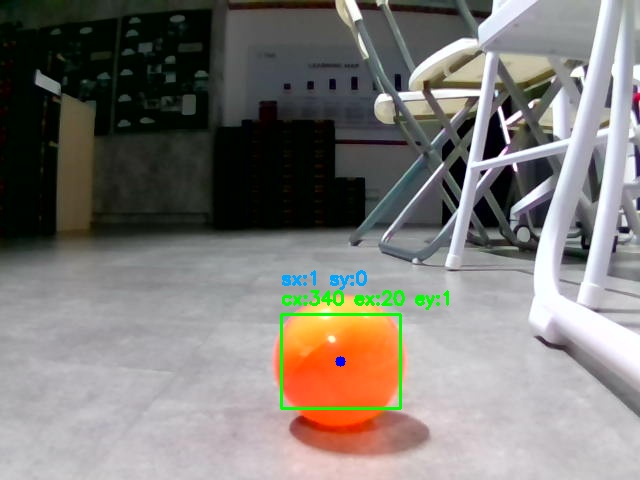

In [6]:
orange_ball_centralizing_approaching()